# 03.1 — Feature Engineering (Light)

This notebook is split in two, by compute requirement rather than by section number:

- **This notebook (`03.1`)** computes every feature that only needs a CPU — word frequency, TF-IDF, sentiment (TextBlob/VADER/Gemini), rhetorical means, adjective/adverb ratio, readability, and evidence use. It runs anywhere: a plain local Python environment or Colab, no GPU required.
- **`03.2_feature_engineering_heavy.ipynb`** computes the features that need a GPU to run in reasonable time — RoBERTa and BART/XLM-RoBERTa classification, and BERT document embeddings — and is best run in Colab with a GPU runtime.

`03.2` loads this notebook's output and continues from there, so **run this notebook first**.

> Loads from `results/02_comments_df_base.csv` (output of `02_data_annotation.ipynb`).
> If running from a fresh clone (e.g. in Colab), only the zipped version `results/02_comments_df_base.csv.zip` is tracked in git — it's loaded automatically as a fallback.


In [1]:
import pandas as pd, zipfile, os

base_csv = '../results/02_comments_df_base.csv'
base_zip = '../results/02_comments_df_base.csv.zip'

if os.path.exists(base_csv):
    comments_df = pd.read_csv(base_csv)
    print('Loaded from 02_comments_df_base.csv')
else:
    with zipfile.ZipFile(base_zip) as z:
        comments_df = pd.read_csv(z.open(z.namelist()[0]))
    print('Loaded from 02_comments_df_base.csv.zip')

print(comments_df.shape)

separator_token = "[SEP]"  # marks the boundary between thread text and final comment when concatenated


Loaded from 02_comments_df_base.csv
(3973, 8)


# ５. Inspecting the Comments DataSet

## 5.1 Words Frequency

Let's see what are the common words in convincing and not-convincing comments:

In [3]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
stop_words = {w.translate(str.maketrans("", "", string.punctuation)) for w in stop_words}  # match punctuation-stripped tokens below (e.g. "dont" for "don't")

# Function to clean text and count words
def get_most_common_words(thread_texts, final_comments, n=20):
    text = " ".join(final_comments)
    # text = " ".join(thread_texts) + " ".join(final_comments)
    words = text.lower().translate(str.maketrans("", "", string.punctuation)).split()
    words = [word for word in words if word not in stop_words]
    # remove single digits, punctuation charcters and single letters:

    return Counter(words).most_common(n)

comments_df["cleaned_thread_text"] = comments_df["cleaned_thread_text"].fillna("")
comments_df["cleaned_final_comment"] = comments_df["cleaned_final_comment"].fillna("")

# Most common words in persuasive arguments
convincing = comments_df[comments_df["is_convincing"] == 1]
persuasive_words = get_most_common_words(convincing['cleaned_thread_text'], convincing["cleaned_final_comment"])
print("Most common words in persuasive arguments:", persuasive_words)

# Most common words in unconvincing arguments
not_convincing = comments_df[comments_df["is_convincing"] == 0]
unconvincing_words = get_most_common_words(not_convincing['cleaned_thread_text'], not_convincing["cleaned_final_comment"])
print("Most common words in unconvincing arguments:", unconvincing_words)


Most common words in persuasive arguments: [('people', 1014), ('would', 592), ('like', 499), ('think', 454), ('one', 386), ('even', 326), ('get', 314), ('also', 275), ('way', 256), ('want', 248), ('make', 247), ('us', 242), ('time', 240), ('much', 236), ('say', 227), ('many', 224), ('things', 223), ('thats', 203), ('going', 203), ('see', 202)]
Most common words in unconvincing arguments: [('people', 1755), ('would', 1209), ('think', 903), ('like', 877), ('one', 687), ('even', 586), ('also', 546), ('get', 545), ('make', 493), ('way', 483), ('thats', 480), ('time', 463), ('much', 452), ('could', 442), ('know', 412), ('want', 410), ('point', 408), ('say', 405), ('really', 396), ('someone', 381)]


[nltk_data] Downloading package stopwords to /Users/dikla/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


We see that in both convincing and unconvincing comments the most common words list is very similar, so it does not provide any meaningful insights.

## 5.2 TF-IDF


TF-IDF or Word2Vec to compare persuasive vs. unconvincing arguments.

In [4]:
def get_comment_and_thread(comment_first=False, is_convincing=None, include_sep=True):
  if is_convincing is not None:
    df = comments_df[comments_df["is_convincing"] == is_convincing]
  else:
    df = comments_df

  if include_sep:
    sep = "\n" + separator_token + "\n"
  else:
    sep = "\n"

  if comment_first:
    return df['final_comment'] + sep + df['thread_text'].fillna("")

  return df['thread_text'].fillna("") + sep + df['final_comment']

In [5]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf_words(texts, top_n=10):
    """Compute TF-IDF and return the top N words with highest scores."""
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    # Compute the max TF-IDF score for each word across all documents
    max_tfidf_scores = np.max(tfidf_matrix.toarray(), axis=0)

    # Get indices of the top N words
    top_indices = np.argsort(max_tfidf_scores)[::-1][:top_n]

    # Retrieve the words and their scores
    top_words = [(feature_names[i], max_tfidf_scores[i]) for i in top_indices]
    return top_words



top_words_all = get_top_tfidf_words(get_comment_and_thread(include_sep=False))  # we don't want the separator to be included in the tf-idf calculation
print("Top 10 words in the entire dataset:", top_words_all)

convincing_texts = get_comment_and_thread(is_convincing=1, include_sep=False)
top_words_convincing = get_top_tfidf_words(convincing_texts)
print("\nTop 10 words in convincing comments:", top_words_convincing)

non_convincing_texts = get_comment_and_thread(is_convincing=0, include_sep=False)
top_words_non_convincing = get_top_tfidf_words(non_convincing_texts)
print("\nTop 10 words in non-convincing comments:", top_words_non_convincing)


Top 10 words in the entire dataset: [('suspiciouslyspecific', np.float64(1.0)), ('good', np.float64(1.0)), ('delta', np.float64(1.0)), ('yes', np.float64(1.0)), ('logistics', np.float64(1.0)), ('blank', np.float64(1.0)), ('source', np.float64(1.0)), ('agree', np.float64(1.0)), ('right', np.float64(1.0)), ('themonkeyspaw', np.float64(1.0))]

Top 10 words in convincing comments: [('la', np.float64(0.7796031655183068)), ('chugga', np.float64(0.7626626421349926)), ('organizers', np.float64(0.7071067811865475)), ('reenactment', np.float64(0.7071067811865475)), ('dog', np.float64(0.6795135126588502)), ('disney', np.float64(0.6644333537194596)), ('autisum', np.float64(0.6631323385808545)), ('offended', np.float64(0.6629148964956889)), ('culture', np.float64(0.6562246031356688)), ('btw', np.float64(0.6497722540930019))]

Top 10 words in non-convincing comments: [('themonkeyspaw', np.float64(1.0)), ('suspiciouslyspecific', np.float64(1.0)), ('agree', np.float64(1.0)), ('delta', np.float64(1.0))

We can see that the results are not very meaningful. It makes sense that the list of high-score TF-IDF does not provide much insight, because this forum includes posts in various subjects and for each subject probably different words are used.

We hoped to see some words that may be used in multiple convincing examples, but we see that it is not the case.

## Shared utilities

Helper functions reused by several sections below (their natural "home" section is in `03.2`, since that's where they're first needed there too, but the light sections here need them first).

In [2]:
import re
def do_calc_feature(feature, func, remove_urls=False, switch_order=False):
  for index, row in comments_df.iterrows():
    if pd.isna(row[feature]):  # calculate only if wasn't calculated yet
      print(f"Calculating {feature} for index {index}")
      if not isinstance(row['thread_text'], str):
        text = row['final_comment']
      elif switch_order:
        text = row['final_comment'] + "\n" + row['thread_text']
      else:
        text = row['thread_text'] + "\n" + row['final_comment']

      if remove_urls:
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
      comments_df.at[index, feature] = func(text)

In [3]:
import re
def do_calc_feature_op(feature, func, remove_urls=False):
  for index, row in op_df.iterrows():
    if pd.isna(row[feature]):  # calculate only if wasn't calculated yet
      print(f"Calculating {feature} for index {index}")
      text = row['original_post']

      if remove_urls:
        text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
      op_df.at[index, feature] = func(text)

In [4]:
import matplotlib.pyplot as plt

def plot_category_histogram(df, column_name, display_name):
    """
    Plots a histogram showing the distribution of convincing and non-convincing comments for each category in the specified column.

    Args:
        df: The pandas DataFrame containing the data.
        column_name: The name of the column containing the categories.
    """

    convincing_counts = df[df['is_convincing'] == 1][column_name].value_counts()
    non_convincing_counts = df[df['is_convincing'] == 0][column_name].value_counts()

    categories = convincing_counts.index.union(non_convincing_counts.index)
    convincing_counts = convincing_counts.reindex(categories, fill_value=0)
    non_convincing_counts = non_convincing_counts.reindex(categories, fill_value=0)

    width = 0.4
    x = range(len(categories))
    fig, ax = plt.subplots(figsize=(12,6))
    rects1 = ax.bar([i - width/2 for i in x], convincing_counts, width, label='Convincing', color='green')
    rects2 = ax.bar([i + width/2 for i in x], non_convincing_counts, width, label='Non-Convincing', color='red')

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
    autolabel(rects1)
    autolabel(rects2)

    ax.set_xlabel(display_name)
    ax.set_ylabel('Number of Comments')
    ax.set_title(f'Number of Convincing and Non-Convincing Comments per {display_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# ６. Feature engineering


We would like to find the characteristics of convincing arguments. We will create several features that can be helpful in identifying a convincing argument, and the new features can later be used in a predictive model.

In [5]:
untrusted_features = []  # feature names we don't trust; saved to results/untrusted_features.json for 04_model_training.ipynb to run with/without


## 6.1 Sentiment Analysis

Check whether sentiment (positive/negative tone) correlates with persuasiveness

### TextBlob

In [6]:
def concatenate_columns(df):
  """
  Concatenates 'thread_text' and 'final_comment' columns with a space in between.

  Args:
    df: pandas DataFrame with 'thread_text' and 'final_comment' columns.

  Returns:
    A new column named 'concatenated_text' with the concatenated text.
    Returns the original DataFrame if either column is missing.
  """
  if not all(col in df.columns for col in ['thread_text', 'final_comment']):
    print("Error: 'thread_text' or 'final_comment' column not found in DataFrame.")
    return df

  df['concatenated_text'] = df['thread_text'] + "\n" + separator_token + "\n" + df['final_comment']
  return df


In [12]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # Range: -1 (negative) to +1 (positive)

comments_df["sentiment"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment
count,3973.000000,3973.000000
mean,0.161339,0.090754
std,0.367890,0.174923
min,0.000000,-1.000000
25%,0.000000,0.000000
50%,0.000000,0.087925
75%,0.000000,0.175000
max,1.000000,1.000000


In [7]:
def plot_feature(feature_name, feature_disp_name, bin_width, width = 0.4, figsize=(12, 6)):
  import matplotlib.pyplot as plt

  min_val = comments_df[feature_name].min()
  max_val = comments_df[feature_name].max()

  bins = [min_val + i * bin_width for i in range(int((max_val - min_val) / bin_width) + 2)]

  # Count convincing and non-convincing comments in each bin
  convincing_counts = []
  non_convincing_counts = []
  bin_labels = []

  for i in range(len(bins) - 1):
      lower_bound = bins[i]
      upper_bound = bins[i+1]
      bin_comments = comments_df[(comments_df[feature_name] >= lower_bound) & (comments_df[feature_name] < upper_bound)]
      convincing_count = bin_comments[bin_comments['is_convincing'] == 1].shape[0]
      non_convincing_count = bin_comments[bin_comments['is_convincing'] == 0].shape[0]
      convincing_counts.append(convincing_count)
      non_convincing_counts.append(non_convincing_count)
      bin_labels.append(f'{lower_bound:.2f}-{upper_bound:.2f}')


  # Plotting the histogram
  x = range(len(bin_labels))

  fig, ax = plt.subplots(figsize=figsize)
  rects1 = ax.bar([i - width/2 for i in x], convincing_counts, width, label='Convincing', color='green')
  rects2 = ax.bar([i + width/2 for i in x], non_convincing_counts, width, label='Non-Convincing', color='red')

  # Add labels to the bars
  def autolabel(rects):
      for rect in rects:
          height = rect.get_height()
          ax.annotate('{}'.format(height),
                      xy=(rect.get_x() + rect.get_width() / 2, height),
                      xytext=(0, 3),  # 3 points vertical offset
                      textcoords="offset points",
                      ha='center', va='bottom')

  autolabel(rects1)
  autolabel(rects2)


  ax.set_xlabel(f'{feature_disp_name} Bin')
  ax.set_ylabel('Number of Comments')
  ax.set_title(f'Number of Convincing and Non-Convincing Comments per {feature_disp_name} Bin')
  ax.set_xticks(x)
  ax.set_xticklabels(bin_labels)
  ax.legend()
  plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
  plt.tight_layout()
  plt.show()

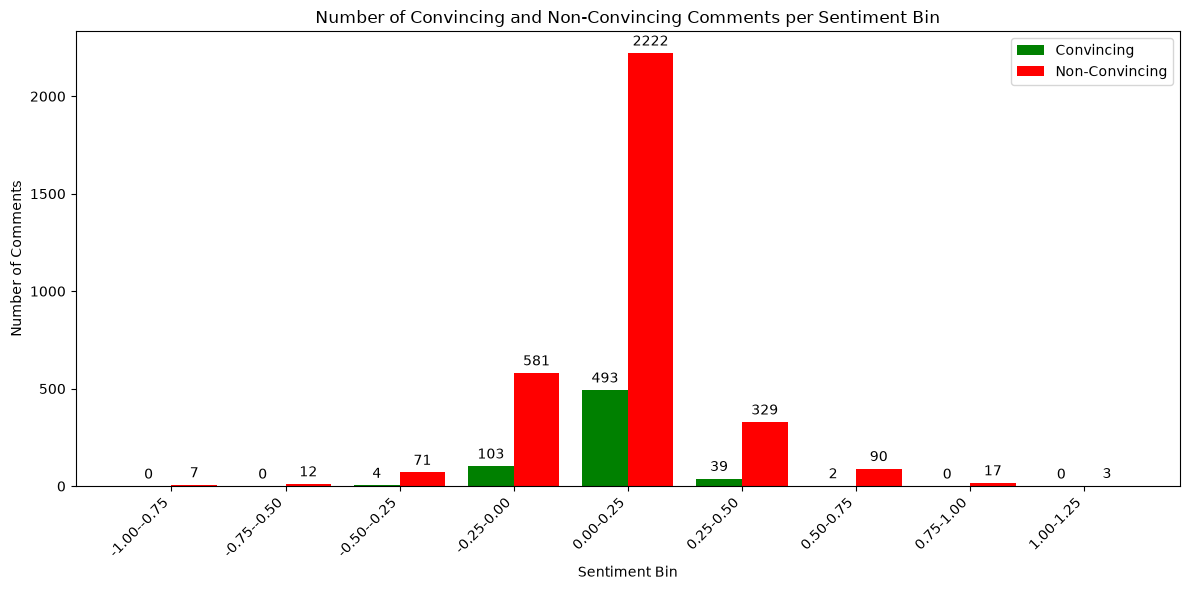

In [14]:
plot_feature('sentiment', 'Sentiment', 0.25)

In [8]:
def show_example_comments(feature_name='sentiment'):
  # Find 3 comments with minimal sentiment
  min_sentiment_comments = comments_df.nsmallest(3, feature_name)
  for index, row in min_sentiment_comments.iterrows():
      print(f"Minimal Sentiment Comment (Sentiment: {row[feature_name]:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

  # Find 3 comments with maximal sentiment
  max_sentiment_comments = comments_df.nlargest(3, feature_name)
  for index, row in max_sentiment_comments.iterrows():
      print(f"Maximal Sentiment Comment (Sentiment: {row[feature_name]:.2f}):")
      print(f"  Thread Text: {row['thread_text']}")
      print(f"  Final Comment: {row['final_comment']}")
      print("-" * 20)

In [16]:
show_example_comments()

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: If noone can decide what is evil then there's nothing evil about schadenfreude
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: You're looking for r/TrueUnpopularOpinion. Some shocking opinions, but that's the nature of the beast.
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: Thats probably the worst example ever
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: nan
  Final Comment: I wouldn’t have thought of that, but I feel it captures the sentiment perfectly.
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: What would be the alternative?  An anarchosyndicalist commune, with someone taking turns to act as a sort of executive officer of the week?  


  Final Comment: > What would be the alternative? An anarchosyndicalist commune, wit

The TextBlob way of identifying the sentiment is based on scoring each word in the text and taking the average score. This approach is less suitable for texts as long as ours. As we can see in the example texts, the sentiment is not identified very well, so we will try a more sophisticated approach, the VADER module.

In [17]:
comments_df = comments_df.drop(columns=['sentiment'])  # drop the TextBlob attempt entirely - not accurate enough to keep, VADER's sentiment_vader replaces it


### VADER module

In [ ]:
!pip install vaderSentiment

In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

In [19]:
comments_df["sentiment_vader"] = (comments_df['thread_text'].fillna("") + "\n" + separator_token + "\n" + comments_df['final_comment']).apply(get_sentiment)

comments_df.describe()

,is_convincing,sentiment_vader
count,3973.000000,3973.000000
mean,0.161339,0.143824
std,0.367890,0.691135
min,0.000000,-0.999900
25%,0.000000,-0.504000
50%,0.000000,0.238200
75%,0.000000,0.828600
max,1.000000,0.999700


In [20]:
show_example_comments('sentiment_vader')

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: Just wanted to chime in with a tiny part. If your living conditions weren't great, or even good, that doesn't give you the right to take it out on people.

I'm a child of war and as shocking that may sound to someone - it gives zero free passing in court. Having PTSD from it is a different thing, but even in cases where someone with PTSD commits a crime he's still held accountable.

Living in a war zone as a child does affect you, but it's not a free pass for being an ass.
[SEP]
He wasn't just *"walking around angry"*.

He had a bat. 

He waited to *be attacked*.

He was ready to ~~hurt~~ kill *any black man* for something one (maybe!) did.

He did it for a *whole week*.


That's really calculated and not something irrational he did while angry. He was making sure that *when* he kills **random black person** it will be said persons fault and LN would play it as self defence. 

Growing up in a war zone does fuck you up, but th

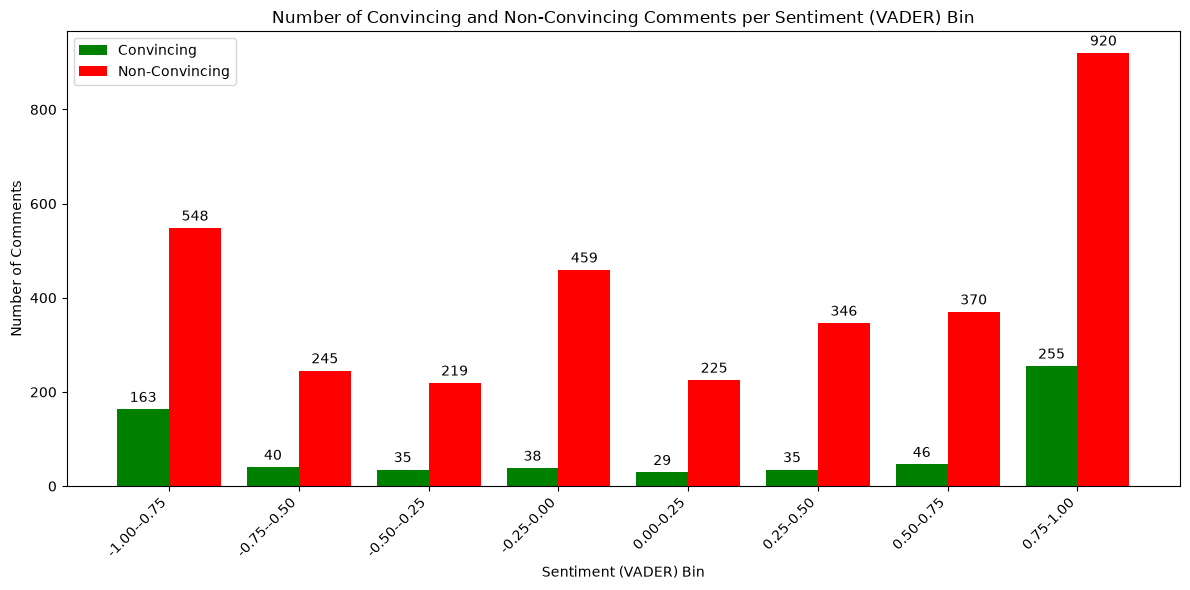

In [21]:
plot_feature('sentiment_vader', 'Sentiment (VADER)', 0.25)

At first glance, it looks like the most convincing comments tend to be either very positive or very negative, while more neutral sentiment corresponds to fewer convincing comments.

The non-convincing comments show a similar pattern: most are scored as very positive, yet were not convincing — which seems counter-intuitive.

Taken at face value, this suggests there's no clean, direct relationship between VADER's sentiment score and whether a comment is convincing.

We're not happy with these results. Looking at the actual examples, VADER is conflating negative *topic* with negative *tone*: the lowest-scored comments are calm, reasoned discussions of dark subjects (racism, police violence, historical injustice) with no rude or hostile language at all, and one of the highest-scored comments is just a dense technical argument about energy technology, not a "pleasant" style. VADER scores on word-level polarity, so words like *racist*, *kill*, or *threat* pull the score down regardless of how respectfully the author is actually writing.

We'll try an LLM-based approach instead, which can reason about the author's tone in context rather than scoring word-by-word.

In [9]:
untrusted_features.append('sentiment_vader')


### LLM-based sentiment (Gemini)

Instead of scoring word-by-word, ask an LLM to rate the author's tone directly, explicitly separating it from the topic being discussed.

In [24]:
import os
from pathlib import Path
from dotenv import load_dotenv
from google import genai

load_dotenv(Path('../.env'))  # .env file must contain GEMINI_API_KEY
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')

# 'gemini-flash-latest' is a rolling alias for Google's current-gen flash model — as of 2026-07-14
# it resolves to 'gemini-3.5-flash' (checked via response.model_version). The project originally
# pinned 'gemini-2.5-flash', which is no longer reachable from new API keys/projects (404 NOT_FOUND
# as of 2026-07-14). To revert to that exact older model on a key that still has access, set
# GEMINI_MODEL = 'gemini-2.5-flash'.
GEMINI_MODEL = 'gemini-flash-latest'  # re-used and re-configured identically in the Tone section below
genai_client = genai.Client(api_key=GEMINI_API_KEY)


In [32]:
import time
from google.genai import errors as genai_errors

def generate_content_with_retry(model, contents, max_retries=5, initial_delay=2):
  delay = initial_delay
  for attempt in range(max_retries):
    try:
      return genai_client.models.generate_content(model=model, contents=contents)
    except genai_errors.ServerError:
      if attempt == max_retries - 1:
        raise
      print(f"Gemini overloaded (503), retrying in {delay}s...")
      time.sleep(delay)
      delay *= 2


In [35]:
sentiment_llm_prompt_prefix = """Rate the sentiment of each of the following numbered texts on a scale from -1 (very negative) to 1 (very positive).

Base your score only on the tone and attitude of the person writing (e.g. hostile, dismissive, or rude vs. friendly, respectful, or warm) - NOT on how negative or positive the topic being discussed is. A calm, respectful discussion of a dark or violent topic should score close to neutral, not negative.

Reply with exactly one line per text, in the format "N: score" (matching the numbers below), and nothing else.

Texts:
"""


In [26]:
comments_df['sentiment_llm'] = None


In [36]:
import re

def get_sentiment_llm_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = sentiment_llm_prompt_prefix + numbered_texts
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)

  scores = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)', line)
    if match:
      i, score = int(match.group(1)), float(match.group(2))
      if 0 <= i < len(scores):
        scores[i] = score
  return scores


In [ ]:
BATCH_SIZE = 20

pending_index = comments_df[comments_df['sentiment_llm'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_sentiment_llm_batch([comments_df.loc[i] for i in batch_index])
    for i, score in zip(batch_index, scores):
      comments_df.at[i, 'sentiment_llm'] = score
    comments_df.to_csv('../results/comments_df_sentiment_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [46]:
none_count = comments_df['sentiment_llm'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

comments_df['sentiment_llm'] = pd.to_numeric(comments_df['sentiment_llm'], errors='coerce')
comments_df['sentiment_llm'].describe()


All entries were classified!


count    3973.000000
mean        0.074880
std         0.338943
min        -1.000000
25%        -0.100000
50%         0.100000
75%         0.300000
max         1.000000
Name: sentiment_llm, dtype: float64

In [47]:
show_example_comments('sentiment_llm')

Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: I will dance on their graves until I need to piss.
--------------------
Minimal Sentiment Comment (Sentiment: -1.00):
  Thread Text: nan
  Final Comment: Why don’t you go use a mouth-operated shotgun, you literal human appendix
--------------------
Minimal Sentiment Comment (Sentiment: -0.90):
  Thread Text: nan
  Final Comment: HOW DARE YOU ATTACK MY SON RANCID FUCKBURGER WILLIAMS THE 3rd. 
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: nan
  Final Comment: I saved your post it was so good. Hear hear to that!
--------------------
Maximal Sentiment Comment (Sentiment: 1.00):
  Thread Text: I want to start by expressing how much I respect you for having the balls to engage in this level of self reflection. From my experience, anyone who is willing to examine themselves and question their actions and belief system is showing that they have what it takes to grow and find hap

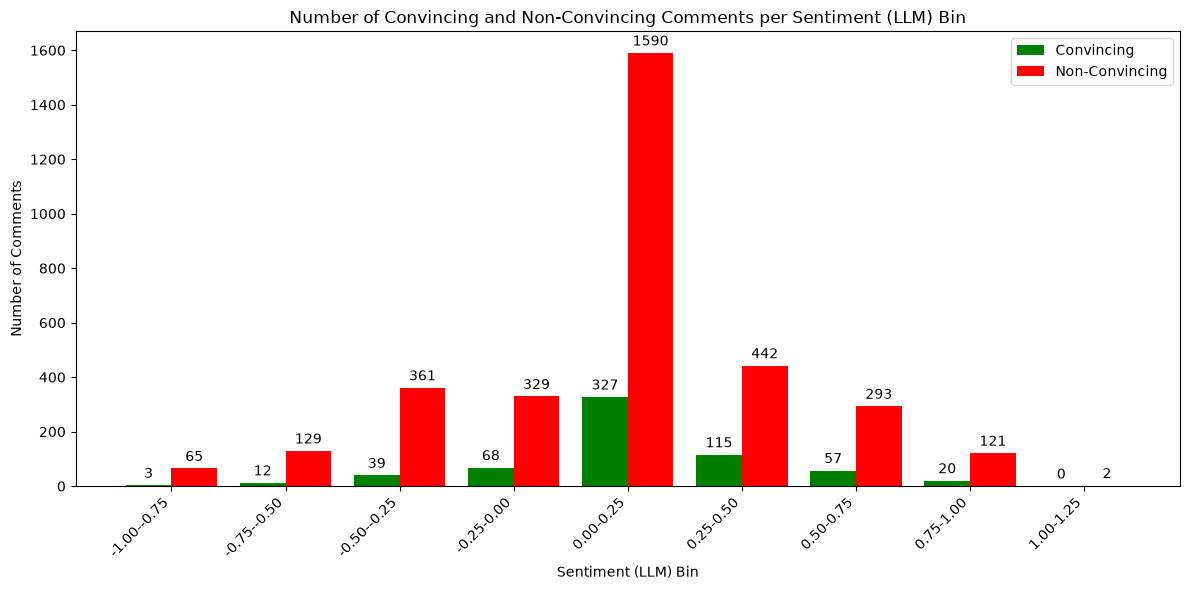

In [48]:
plot_feature('sentiment_llm', 'Sentiment (LLM)', 0.25)

Looking at the example comments above, this approach succeeds where VADER struggled: the most negative examples are genuinely hostile in tone (open insults, gloating, all-caps anger), and the most positive examples are warm and supportive regardless of how heavy the topic is — including a long, serious response about self-worth that still reads as encouraging rather than negative. The tone/topic separation we were hoping for is working as intended.

The chart tells a different story, though. The `0.00-0.25` bin alone accounts for roughly half the dataset, and across the neutral-to-positive range (`-0.25` and up) the ratio of convincing to non-convincing comments stays close to the dataset's overall ~16% convincing rate, with no visible trend. There's a mild dip in the convincing rate at the very negative end, but those bins hold too few comments to draw a real conclusion from.

Unlike the VADER attempt, the issue here isn't that the metric is unreliable — it's that sentiment tone on its own doesn't appear to separate convincing from non-convincing comments. We'll keep `sentiment_llm` as a feature rather than marking it untrusted, since a weak or non-linear relationship might still be picked up by the model, but we don't expect it to be a strong predictor by itself.

## 6.2 Tone (continued from `03.2`)

The RoBERTa-based attempt for this feature is in `03.2_feature_engineering_heavy.ipynb` (it needs a GPU to run in reasonable time). We weren't satisfied with those results (see there for details) and continue here with a Gemini-based approach instead, since that only needs API calls, not GPU.

### Google's Gemini

In [49]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('../.env'))  # .env file must contain GEMINI_API_KEY
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')


In [50]:
from google import genai

genai_client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = 'gemini-flash-latest'  # see the model-choice comment in the Sentiment setup cell above


In [51]:
# let's try with an example text taken randomly from our data set:
test_text = comments_df.iloc[95]['final_comment']
test_text

"If Bernie the lifelong politician can't pass basic cognition and civics tests, then no, he shouldn't be president.   He may be mostly appointing the right people and listening to advisors, but he still has to make tough decisions. \n\nAlthough I believe there already is a cognition test for the president, I remember Trump bragging about passing it"

In [57]:
user_prompt_prefix = """Analyze the tone of each of the following numbered texts and classify it as one of the following: Logical, Passionate, Humorous, Sarcastic, Neutral, or Other.

Reply with exactly one line per text, in the format "N: label" (matching the numbers below), and nothing else.

Texts:
"""


In [60]:
user_prompt = user_prompt_prefix + f"0:\n{test_text}\n"

response = genai_client.models.generate_content(model=GEMINI_MODEL, contents=user_prompt)
classification = response.text.strip()
print(classification)


0: Logical


In [54]:
comments_df['tone_google'] = None

In [67]:
import re

class BlockedResponseError(Exception):
  pass

def get_tone_from_google_ai_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = user_prompt_prefix + numbered_texts
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  classifications = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(classifications):
        classifications[i] = label
  return classifications


In [ ]:
BATCH_SIZE = 20

def classify_tone_batch(batch_index):
  try:
    classifications = get_tone_from_google_ai_batch([comments_df.loc[i] for i in batch_index])
    for i, classification in zip(batch_index, classifications):
      comments_df.at[i, 'tone_google'] = classification
  except BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      comments_df.at[batch_index[0], 'tone_google'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_tone_batch(batch_index[:mid])
      classify_tone_batch(batch_index[mid:])

pending_index = comments_df[comments_df['tone_google'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_tone_batch(batch_index)
    comments_df.to_csv('../results/comments_df_tone_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [69]:
none_count = comments_df['tone_google'].isna().sum()
if none_count == 0:
  print("All entries were classified!")
else:
  print(f"{none_count} entries still need to be classified out of {len(comments_df)}")

All entries were classified!


In [70]:
comments_df['tone_google'].head(20)

0        Logical
1     Passionate
2     Passionate
3        Neutral
4        Logical
5        Neutral
6     Passionate
7        Logical
8        Logical
9     Passionate
10     Sarcastic
11     Sarcastic
12       Logical
13       Logical
14     Sarcastic
15     Sarcastic
16       Logical
17       Logical
18       Neutral
19       Logical
Name: tone_google, dtype: object

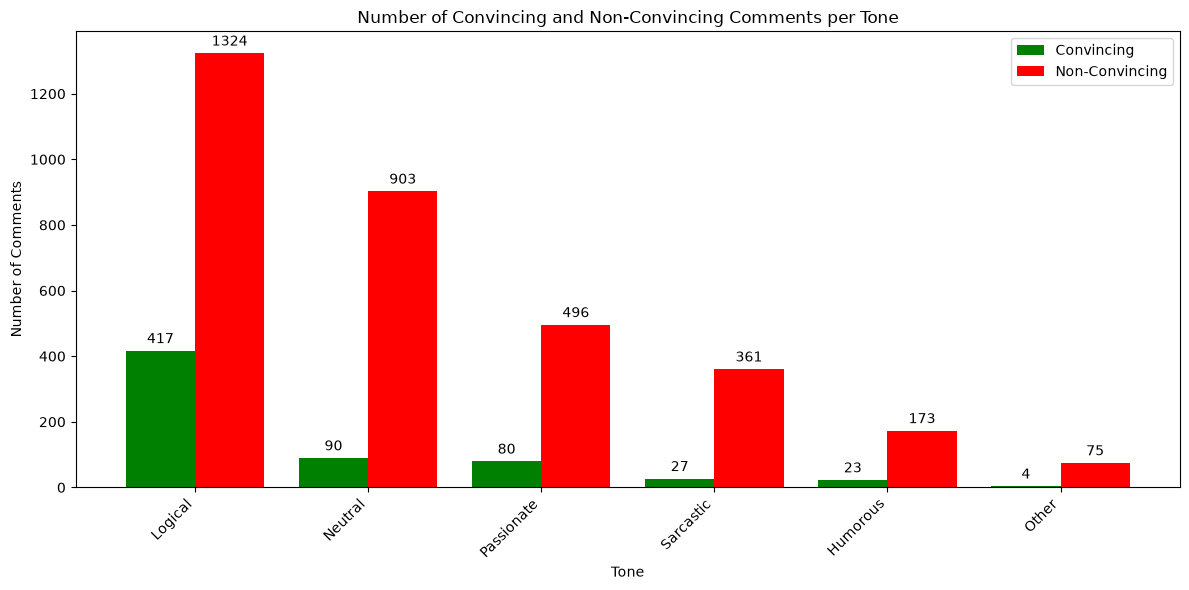

In [71]:
plot_category_histogram(comments_df, 'tone_google', 'Tone')

In [72]:
def show_tone_examples(tone_label):
  print(f"Example for {tone_label}:")
  print(comments_df[comments_df['tone_google'] == tone_label].iloc[0]['final_comment'])
  print("-" * 20)

show_tone_examples("Humorous")
show_tone_examples("Sarcastic")
show_tone_examples("Passionate")

Example for Humorous:
He tweeted he was running for president. That's it.

Elon Musk, who is basically a shit poster, chimed in and replied to his tweet with his "endorsement"

My guess: It's all about Kanyes next album, which will be available for free on the newest tesla or something silly like that.

I have seen no proof that he's **actually** running. Anyone can tweet that they're running for president.

Will it cause more people to write in his name in the ballots? Yes. But they probably would have wrote in Harambe or SpongeBob instead if it wasn't Kanye.
--------------------
Example for Sarcastic:
Case closed boys pack it up!

We’ve been outsmarted by the billionaires again.

The same group of people that never transact with their billions. It just amasses while they sit there doing nothing. 
Definitely not buying high end goods, or flying private jets, or purchasing property or artwork or buying multimillion dollar cars or receiving dividends or selling stock or hoarding large s

`Logical` is by far the most common tone (44% of comments), followed by `Neutral` (25%), `Passionate` (14%), `Sarcastic` (10%), `Humorous` (5%), and `Other` (2%). The examples above confirm the labels are doing what we'd expect: the humorous one jokes about Kanye's presidential run, the sarcastic one drips with mock resignation ("Case closed boys pack it up!"), and the passionate one argues forcefully and directly without either of the other two tones' distance.


The convincing rate also varies clearly by tone, unlike what we saw with the plain sentiment score. `Logical` comments convince at 24.0%, well above the dataset's ~16.1% baseline, while `Sarcastic` (7.0%), `Other` (5.1%), and `Neutral` (9.1%) convince well below it; `Passionate` (13.9%) and `Humorous` (11.7%) land close to baseline. This matches intuition — reasoned argument persuades more often than mockery or flat restatement — so we'll keep `tone_google` as a feature.


## 6.4 Rhetorical means
**Rhetorical means** refer to the strategies and techniques used to persuade or influence an audience in communication. They are central to the art of rhetoric and can be categorized into three main types: **ethos**, **pathos**, and **logos**. Together, these rhetorical means form the foundation of persuasive communication.

**Ethos** appeals to the speaker's credibility and character, aiming to establish trust with the audience.

**Pathos** focuses on evoking emotions, such as sympathy or anger, to connect with the audience on a personal level.

**Logos**, on the other hand, relies on logic and reasoning, using facts, statistics, and logical arguments to persuade the audience.

We would like to create feature with the amount of each rhetorical mean in each text.

Empath is an open-source text analysis library that categorizes words into psychologically meaningful themes, allowing users to extract insights about emotions, topics, and rhetorical strategies from text. We will use this library to calculate scores for each rhethorical mean in our data set.

In [10]:
!pip install empath

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empath: filename=empath-0.89-py3-none-any.whl size=57840 sha256=9c5351723712050397f6b1f93f30cebbbd0bde6b41da1895043f494bb1ab2e7f
  Stored in directory: /Users/dikla/Library/Caches/pip/wheels/b5/93/85/f4e8694df404eb214060dd0e0f3fda14398638f5835b3dde23
Successfully built empath

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [11]:
pathos_categories = ['hate', 'cheerfulness', 'aggression', 'envy', 'anticipation', 'fear', 'nervousness', 'horror', 'suffering', 'pride', 'sadness', 'optimism', 'irritability', 'surprise', 'exasperation', 'zest', 'confusion', 'love', 'sympathy', 'rage', 'emotional', 'joy', 'affection', 'shame', 'torment', 'anger', 'disappointment', 'pain', 'timidity', 'negative_emotion', 'positive_emotion', 'contentment']
ethos_categories = ['office', 'occupation', 'government', 'royalty', 'wealthy', 'journalism', 'banking', 'leader', 'independence', 'dominant_heirarchical', 'military', 'dominant_personality', 'science', 'work', 'philosophy', 'law', 'achievement']
logos_categories = ['money', 'medical_emergency', 'crime', 'dispute', 'government', 'school', 'computer', 'college', 'business', 'driving', 'internet', 'programming', 'economics', 'politics', 'technology', 'negotiate', 'payment']

In [14]:
comments_df['ethos_score'] = None
comments_df['pathos_score'] = None
comments_df['logos_score'] = None

In [34]:
from empath import Empath
import pandas as pd

lexicon = Empath()

def compute_rhetorical_scores():
  for index, row in comments_df.iterrows():
    if pd.isna(row['ethos_score']) or pd.isna(row['pathos_score']) or pd.isna(row['logos_score']):  # calculate only if wasn't calculated yet
      print(f"Calculating rhethorical means for index {index}")
      if isinstance(row['thread_text'], str):
        text = row['thread_text'] + "\n" + row['final_comment']
      else:
        text = row['final_comment']

      analysis = lexicon.analyze(text, normalize=True)  # Normalize to percentage

      ethos_score = sum(analysis[cat] for cat in ethos_categories)
      pathos_score = sum(analysis[cat] for cat in pathos_categories)
      logos_score = sum(analysis[cat] for cat in logos_categories)

      comments_df.at[index, 'ethos_score'] = ethos_score
      comments_df.at[index, 'pathos_score'] = pathos_score
      comments_df.at[index, 'logos_score'] = logos_score

In [35]:
import os

rhetorical_checkpoint = '../results/comments_df_rhetorical_checkpoint.csv'
if os.path.exists(rhetorical_checkpoint):
  comments_df = pd.read_csv(rhetorical_checkpoint)
  print("Loaded from checkpoint")
else:
  compute_rhetorical_scores()
  comments_df.to_csv(rhetorical_checkpoint, index=False)
  print("Computed and saved checkpoint")

rhetorical_score_cols = ['ethos_score', 'pathos_score', 'logos_score']
comments_df[rhetorical_score_cols] = comments_df[rhetorical_score_cols].astype(float)  # stays object dtype after the None init above otherwise


Loaded from checkpoint


Let's plot the distribution of each rhethorical mean in the dataset:

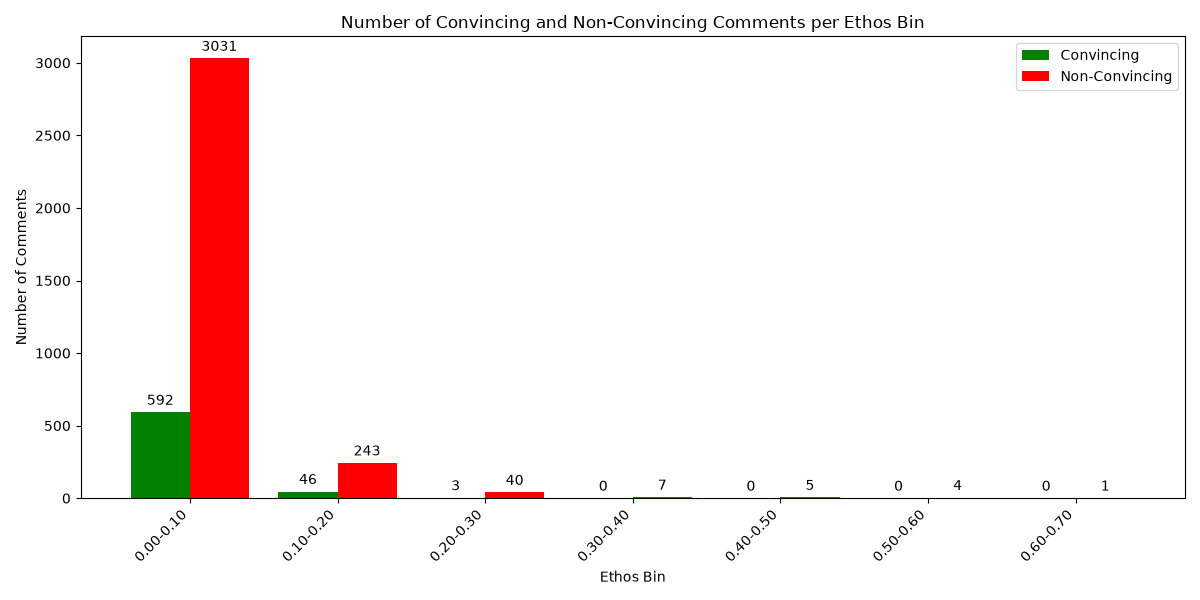

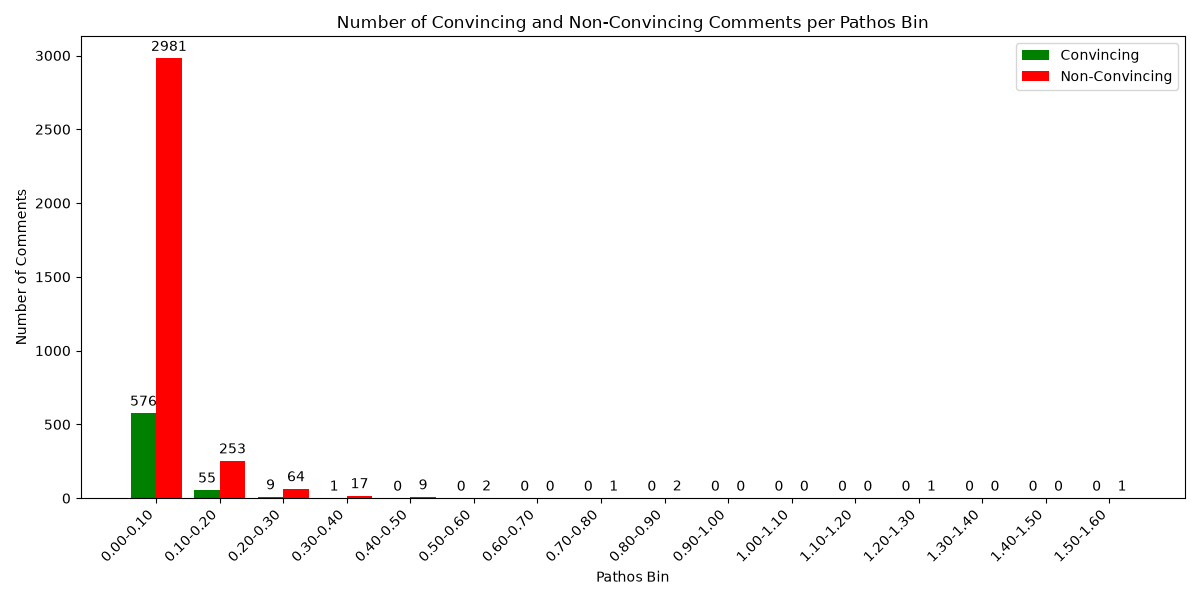

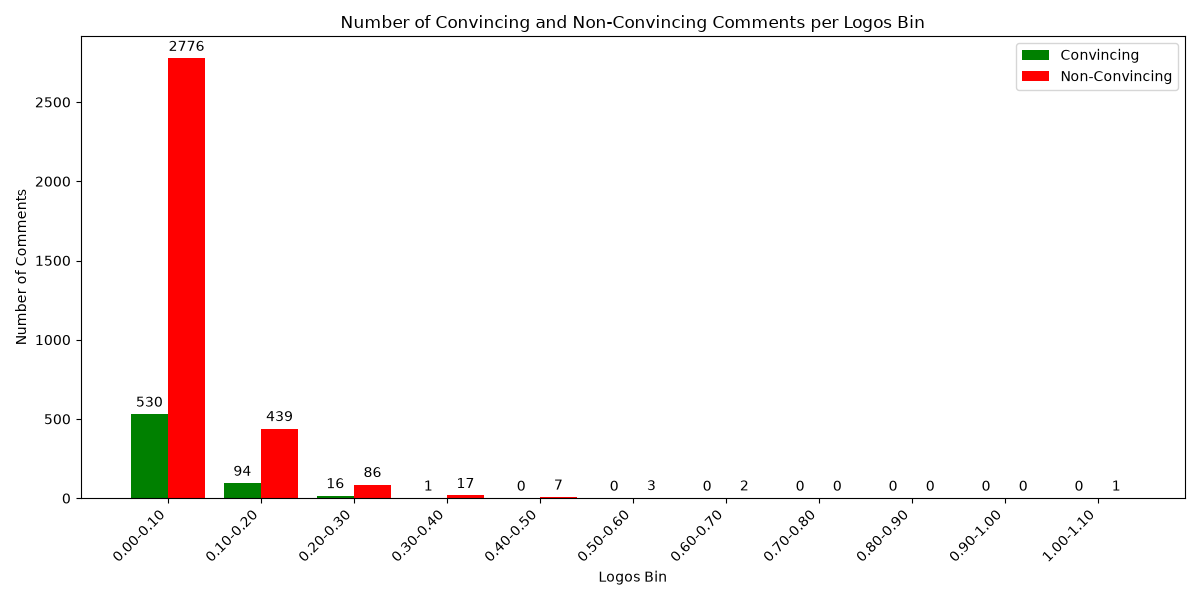

In [36]:
plot_feature('ethos_score', 'Ethos', 0.10)
plot_feature('pathos_score', 'Pathos', 0.10)
plot_feature('logos_score', 'Logos', 0.10)

Examples:

In [37]:
MIN_WORDS_FOR_EXAMPLE = 30  # short comments are noisy here: a single matching word can swing the normalized score close to 1.0

def show_rhethorical_mean_example(feature_name, mode='max'):
  candidates = comments_df[comments_df['final_comment'].str.split().str.len() >= MIN_WORDS_FOR_EXAMPLE]
  row = candidates.nlargest(1, feature_name).iloc[0] if mode == 'max' else candidates.nsmallest(1, feature_name).iloc[0]
  # print the same text the score was computed from, not just final_comment - the score can be driven by thread_text too
  text = row['thread_text'] + "\n" + row['final_comment'] if isinstance(row['thread_text'], str) else row['final_comment']
  print(f"{mode.capitalize()} example for {feature_name} = {row[feature_name]:.2f}:")
  print(text)
  print("-" * 20)

for feature in ['ethos_score', 'pathos_score', 'logos_score']:
  show_rhethorical_mean_example(feature, 'max')
  show_rhethorical_mean_example(feature, 'min')


Max example for ethos_score = 0.39:
A sociopath could pass the test and take advantage of the government better than a non scared person can. There are plenty of crooks in the government who know how the government work
--------------------
Min example for ethos_score = 0.00:
Since 3.81 million shares of amazon are traded daily \*as is\* the impact of 4.34 million more per year (17200 per trading day) shouldn't be that large. Also that would be the most he would ever sell, because his net worth would obviously be shrinking

 [https://finbox.com/NASDAQGS:AMZN/explorer/volume\_avg\_3m](https://finbox.com/NASDAQGS:AMZN/explorer/volume_avg_3m)
--------------------
Max example for pathos_score = 0.41:
Disney is part of an Oligopoly.  While not as bad as a Monopoly, it can still be very bad for consumers.  However Disney is pumping out seriously quality movies, better then before they bought all these big companies recently.  
--------------------
Min example for pathos_score = 0.00:
Jeff Be

In [38]:
baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

for feature in ['ethos_score', 'pathos_score', 'logos_score']:
  low = comments_df[comments_df[feature] < 0.10]
  high = comments_df[comments_df[feature] >= 0.10]
  print(f"{feature}: below 0.10 -> {low['is_convincing'].mean():.1%} (n={len(low)}), "
        f"0.10 and above -> {high['is_convincing'].mean():.1%} (n={len(high)})")


Baseline convincing rate: 16.1%

ethos_score: below 0.10 -> 16.3% (n=3623), 0.10 and above -> 14.0% (n=349)
pathos_score: below 0.10 -> 16.2% (n=3557), 0.10 and above -> 15.7% (n=415)
logos_score: below 0.10 -> 16.0% (n=3306), 0.10 and above -> 16.7% (n=666)


With longer comments only (30+ words, so a single matching word can't swing a short comment's normalized score to 1.0), the extreme examples make more intuitive sense: the high-ethos example leans on institutional/authority language, the high-pathos one is emotionally charged, and the high-logos one leans on factual/topical vocabulary, while the low-scoring examples for each are simply comments where none of that category's words happen to appear.

But the convincing-rate breakdown above is what actually settles it. Unlike tone (`Logical` at 24.0% vs. baseline ~16.1%), none of the three scores show a meaningful split: comments at 0.10 or higher land within a couple of points of the ~16% baseline in every case, and those higher bins only hold a few hundred comments each. Empath's category matches are sparse and topic-driven rather than structural - `logos`, for instance, overlaps with subject matter like politics or technology more than with argument quality - so they don't function as a rhetorical-strategy signal here. Rather than drop them outright, we'll mark them as untrusted (the same treatment `sentiment_vader` got) and let `04_model_training.ipynb` decide whether they still carry weak signal - and try an LLM-based version below, the same approach that worked for sentiment and tone.

In [39]:
untrusted_features.append('ethos_score')
untrusted_features.append('pathos_score')
untrusted_features.append('logos_score')


### LLM-based rhetorical means (Gemini)

Empath's word-list approach conflates *topic* with *rhetorical strategy* - `logos` fires on any mention of politics or technology, regardless of whether the comment is actually reasoning logically, the same problem VADER had with sentiment vs. topic. Let's ask Gemini to rate the degree of each rhetorical appeal directly instead, the same approach that worked for sentiment and tone above.

In [20]:
import os
from pathlib import Path
from dotenv import load_dotenv
from google import genai

load_dotenv(Path('../.env'))  # .env file must contain GEMINI_API_KEY
GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
genai_client = genai.Client(api_key=GEMINI_API_KEY)
GEMINI_MODEL = 'gemini-flash-latest'  # see the model-choice comment in the Sentiment setup cell above


In [21]:
import time
from google.genai import errors as genai_errors

def generate_content_with_retry(model, contents, max_retries=5, initial_delay=2):
  delay = initial_delay
  for attempt in range(max_retries):
    try:
      return genai_client.models.generate_content(model=model, contents=contents)
    except genai_errors.ServerError:
      if attempt == max_retries - 1:
        raise
      print(f"Gemini overloaded (503), retrying in {delay}s...")
      time.sleep(delay)
      delay *= 2


In [22]:
rhetorical_llm_prompt_prefix = """Rate each of the following numbered texts on three rhetorical appeals, each on a scale from 0 (not present) to 1 (strongly present):

- ethos: appeals to the author's credibility, authority, expertise, or character
- pathos: appeals to emotion (sympathy, anger, fear, hope, etc.)
- logos: appeals to logic and reasoning (facts, statistics, cause-and-effect argument)

These are not mutually exclusive - a text can score high on more than one, or low on all three.

Reply with exactly one line per text, in the format "N: ethos,pathos,logos" (matching the numbers below), and nothing else.

Texts:
"""


In [23]:
comments_df['ethos_llm'] = None
comments_df['pathos_llm'] = None
comments_df['logos_llm'] = None


In [24]:
import re

def get_rhetorical_llm_batch(rows):
  texts = []
  for row in rows:
    if isinstance(row['thread_text'], str):
      texts.append(row['thread_text'] + "\n" + row['final_comment'])
    else:
      texts.append(row['final_comment'])

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = rhetorical_llm_prompt_prefix + numbered_texts
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)

  scores = [(None, None, None)] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)\s*,\s*(-?\d*\.?\d+)', line)
    if match:
      i = int(match.group(1))
      if 0 <= i < len(scores):
        scores[i] = (float(match.group(2)), float(match.group(3)), float(match.group(4)))
  return scores


In [ ]:
BATCH_SIZE = 20

pending_index = comments_df[comments_df['ethos_llm'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a score
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    scores = get_rhetorical_llm_batch([comments_df.loc[i] for i in batch_index])
    for i, (ethos, pathos, logos) in zip(batch_index, scores):
      comments_df.at[i, 'ethos_llm'] = ethos
      comments_df.at[i, 'pathos_llm'] = pathos
      comments_df.at[i, 'logos_llm'] = logos
    comments_df.to_csv('../results/comments_df_rhetorical_llm_checkpoint.csv', index=False)
    print(f"scored rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


In [28]:
for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  none_count = comments_df[feature].isna().sum()
  if none_count == 0:
    print(f"{feature}: all entries were classified!")
  else:
    print(f"{feature}: {none_count} entries still need to be classified out of {len(comments_df)}")
  comments_df[feature] = pd.to_numeric(comments_df[feature], errors='coerce')


ethos_llm: all entries were classified!
pathos_llm: all entries were classified!
logos_llm: all entries were classified!


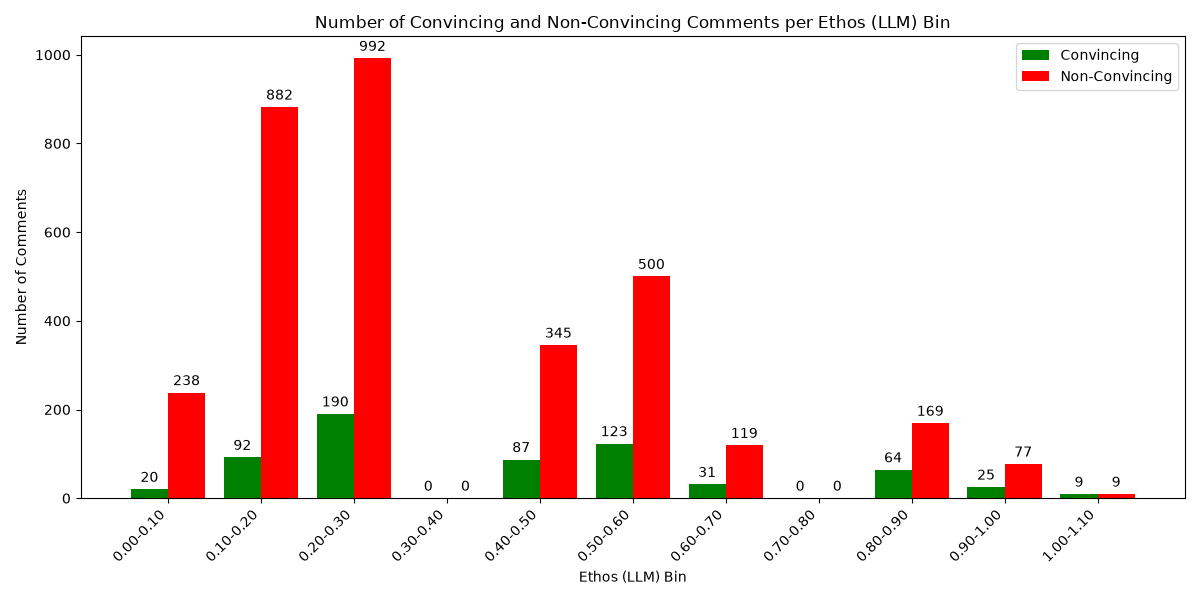

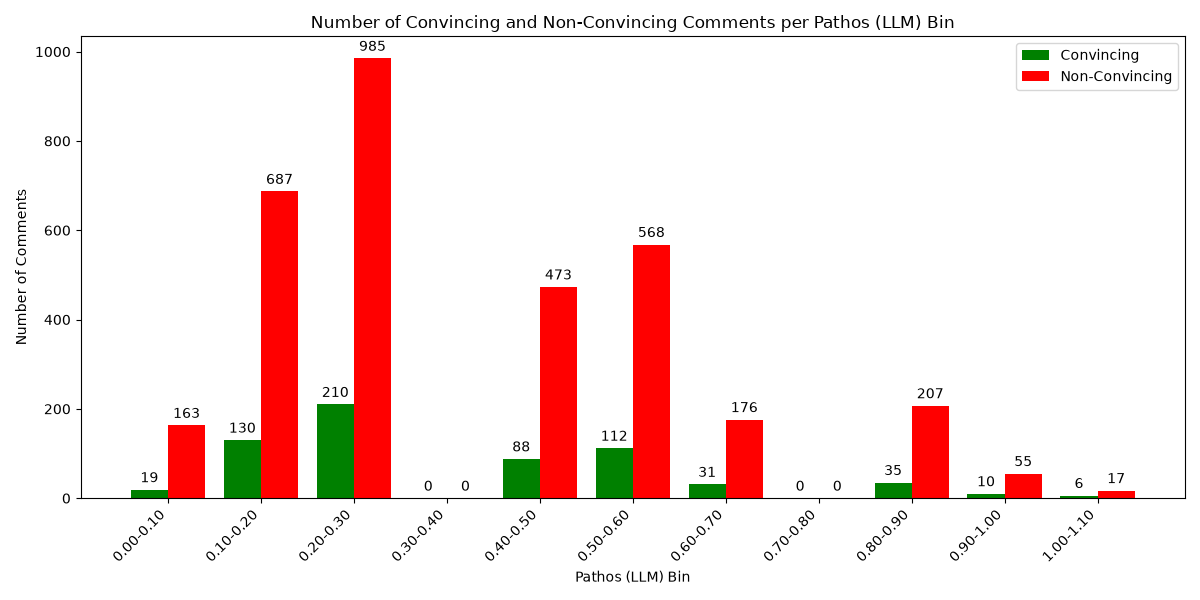

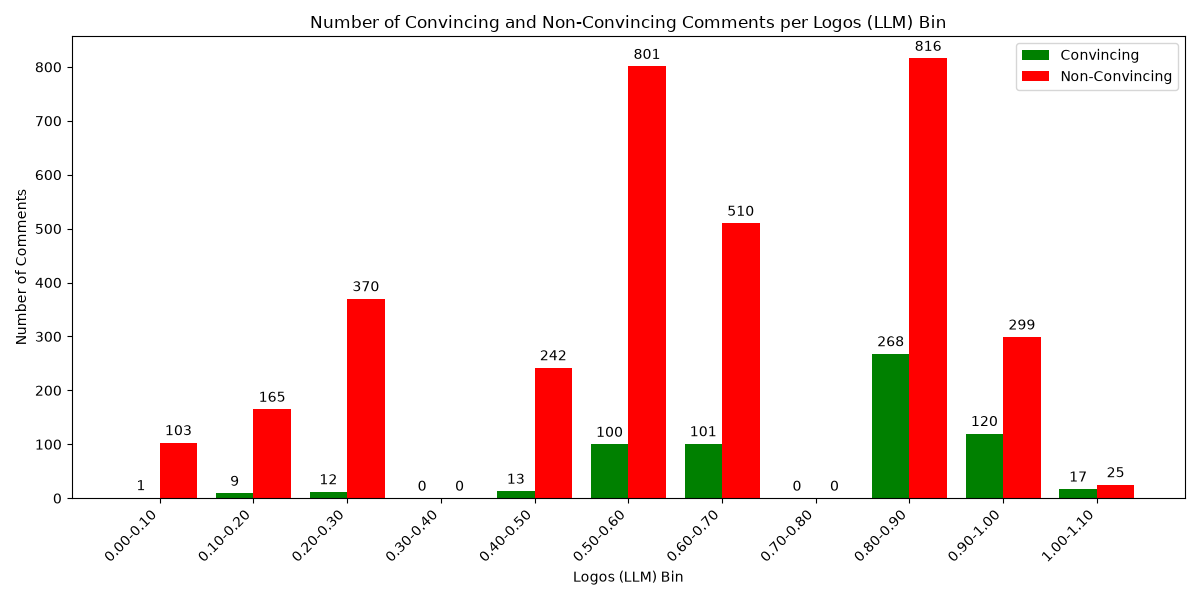

In [29]:
plot_feature('ethos_llm', 'Ethos (LLM)', 0.10)
plot_feature('pathos_llm', 'Pathos (LLM)', 0.10)
plot_feature('logos_llm', 'Logos (LLM)', 0.10)


In [30]:
def show_rhetorical_llm_example(feature_name, mode='max'):
  row = comments_df.nlargest(1, feature_name).iloc[0] if mode == 'max' else comments_df.nsmallest(1, feature_name).iloc[0]
  text = row['thread_text'] + "\n" + row['final_comment'] if isinstance(row['thread_text'], str) else row['final_comment']
  print(f"{mode.capitalize()} example for {feature_name} = {row[feature_name]:.2f}:")
  print(text)
  print("-" * 20)

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  show_rhetorical_llm_example(feature, 'max')
  show_rhetorical_llm_example(feature, 'min')


Max example for ethos_llm = 1.00:
The low hanging issue is that these news networks claim that what they spout is not "news", but "entertainment".

Despite being a news network.

There's gotta be a way to close that loophole at least.

Here's an article that addresses exactly what you're referring to: https://www.npr.org/2020/09/29/917747123/you-literally-cant-believe-the-facts-tucker-carlson-tells-you-so-say-fox-s-lawye

This has been raised for Tucker Carlson and Rachel Maddow, both of whom were deemed to be clearly lying in the eyes of a "reasonable viewer".

Of course the words "clearly lying" aren't used. They are replaced with words like "rhetoric", "hyperbole", "exaggeration", "non-literal", "commentary", and "figurative".

If there's no law preventing figurative and hyperbolic commentary from talking heads (sure, that's fine), maybe we should consider forcing them to make that distinction apparent. 

Their entire legal argument is grounded on the expectation of "reasonable view

In [45]:
baseline_rate = comments_df['is_convincing'].mean()
print(f"Baseline convincing rate: {baseline_rate:.1%}\n")

for feature in ['ethos_llm', 'pathos_llm', 'logos_llm']:
  low = comments_df[comments_df[feature] < 0.5]
  high = comments_df[comments_df[feature] >= 0.5]
  print(f"{feature}: below 0.5 -> {low['is_convincing'].mean():.1%} (n={len(low)}), "
        f"0.5 and above -> {high['is_convincing'].mean():.1%} (n={len(high)})")


Baseline convincing rate: 16.1%

ethos_llm: below 0.5 -> 13.7% (n=2846), 0.5 and above -> 22.4% (n=1126)
pathos_llm: below 0.5 -> 16.2% (n=2755), 0.5 and above -> 15.9% (n=1217)
logos_llm: below 0.5 -> 3.8% (n=915), 0.5 and above -> 19.8% (n=3057)


The three scores landed very differently once measured directly instead of through Empath's word lists.

`logos_llm` shows the widest split we've seen in this notebook: comments scoring below 0.5 convince only 3.8% of the time (n=915), while those at 0.5 or above convince 19.8% of the time (n=3057) - a ~5.2x gap between the two bins, wider than `tone_google`'s `Logical` vs. `Sarcastic` split (3.4x). It also fixes the exact problem `logos_score` had: rather than firing on any mention of politics or technology, it tracks genuine reasoning - the max-scoring example is a long, well-sourced rebuttal that walks through a study's methodology and conclusions, while the min-scoring example is a one-line "hear hear" reply with no argument at all.

`ethos_llm` shows a real but smaller split: 13.7% convincing below 0.5 (n=2846) vs. 22.4% at or above (n=1126). (The highest-scoring example here used to be an automated moderator "thread locked" notice rather than real author content - see the data-quality-check cells in `02_data_annotation.ipynb` - now removed at the source. The current top example is a comment arguing that news networks shouldn't get to hide behind "commentary" framing to dodge accountability, which reads as a genuine credibility/accountability appeal.)

`pathos_llm` is essentially flat (16.2% vs. 15.9%, against a ~16.1% baseline) - emotional appeal on its own doesn't seem to predict persuasiveness here, the same conclusion we reached for `sentiment_llm` and VADER. We'll keep it as a feature anyway rather than marking it untrusted outright, in case a non-linear or combined effect shows up once the model sees it alongside the others.

## 6.5 Adjective-Adverb Ratio

The **Adjective-Adverb Ratio**, also called the **Descriptive Density Ratio** measures the proportion of adjectives and adverbs in a text relative to the total word count. A higher ratio indicates a more expressive or emotionally charged writing style, while a lower ratio suggests a more concise, factual, and objective tone.

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

In [47]:
import spacy

nlp = spacy.load('en_core_web_sm')

def get_adjective_adverb_ratio(text):
  doc = nlp(text)
  adjectives = [token.text for token in doc if token.pos_ == 'ADJ']
  adverbs = [token.text for token in doc if token.pos_ == 'ADV']
  return len(adjectives) / len(adverbs) if len(adverbs) > 0 else np.inf

In [48]:
comments_df['adj_adv_ratio'] = None

In [ ]:
import numpy as np
do_calc_feature("adj_adv_ratio", get_adjective_adverb_ratio)

We want to plot the results. Rows with no adverbs get an infinite ratio, which isn't usable for plotting or stats, so we cap them at a sentinel value just above the observed finite max. A small margin keeps these rows ranked as the highest without an oversized value skewing the chart's scale or the mean/std.

In [58]:
finite_max = comments_df['adj_adv_ratio'].replace(np.inf, np.nan).max()
sentinel = finite_max + 2  # small margin above the real max keeps infinite-ratio rows the highest without distorting the plot

print("The finite max of adj_adv_ratio is:", finite_max)
print("The sentinel value for infinite ratios is:", sentinel)

comments_df['adj_adv_ratio_edited'] = comments_df['adj_adv_ratio'].replace(np.inf, sentinel).astype(float)

The finite max of adj_adv_ratio is: 15.0
The sentinel value for infinite ratios is: 17.0


A value of `sentinel` (currently 17.0, printed above) is not a real measurement — it marks a comment that has at least one adjective but zero adverbs, where the true ratio is undefined (division by zero, i.e. mathematically infinite). We cap all such comments at the same fixed sentinel purely so the column stays plottable and comparable; it should be read as "infinite/undefined ratio", not as "17 times more adjectives than adverbs".

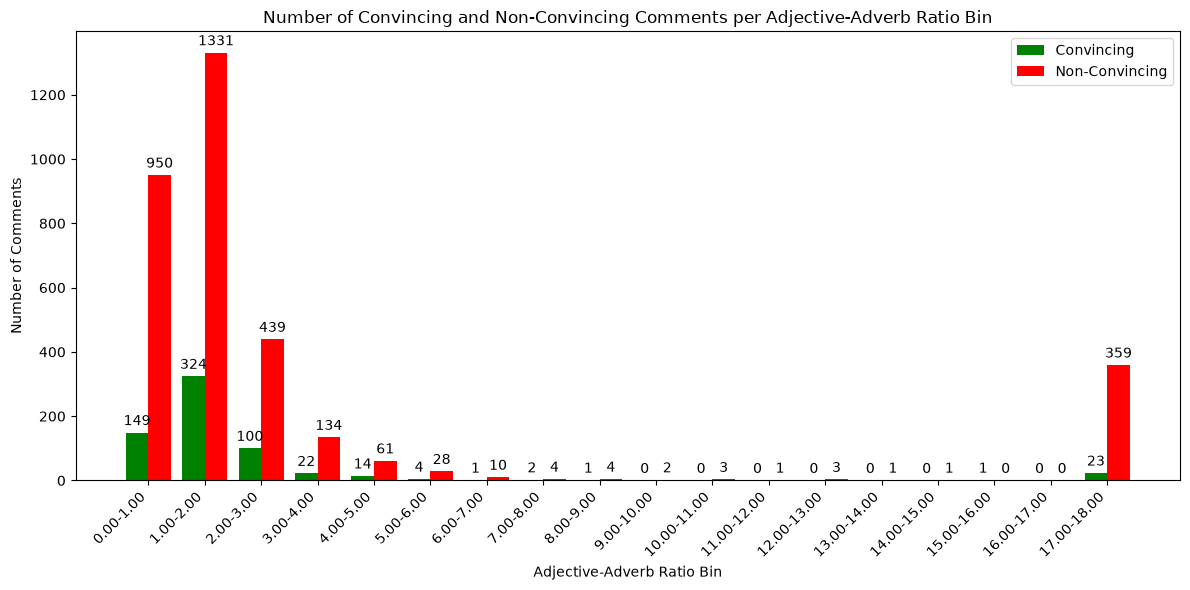

In [60]:
plot_feature('adj_adv_ratio_edited', 'Adjective-Adverb Ratio', 1)

In [61]:
# Drop the 'adj_adv_ratio' column
comments_df = comments_df.drop('adj_adv_ratio', axis=1)

# Rename 'adj_adv_ratio_edited' to 'adj_adv_ratio'
comments_df = comments_df.rename(columns={'adj_adv_ratio_edited': 'adj_adv_ratio'})


In [63]:
import numpy as np

# "Infinite" ratio: at least one adjective, zero adverbs detected - capped at `sentinel` (see explanation above)
infinite_ratio_rows = comments_df[comments_df['adj_adv_ratio'] == sentinel]
infinite_example_row = infinite_ratio_rows.iloc[0]
print(f"Example for 'infinite' Adj/Adv ratio (capped at {sentinel}, {len(infinite_ratio_rows)} such comments in the dataset):")
print(infinite_example_row['final_comment'])
print("-" * 20)

# Highest genuinely finite ratio (excludes the capped 'infinite' rows)
finite_ratio_rows = comments_df[comments_df['adj_adv_ratio'] < sentinel]
max_finite_row = finite_ratio_rows.loc[finite_ratio_rows['adj_adv_ratio'].idxmax()]
print(f"Example for highest finite Adj/Adv ratio ({max_finite_row['adj_adv_ratio']}):")
print(max_finite_row['final_comment'])
print("-" * 20)

min_adj_adv_ratio_row = comments_df.loc[comments_df['adj_adv_ratio'].idxmin()]
print(f"Example for low Adj/Adv ratio ({min_adj_adv_ratio_row['adj_adv_ratio']}):")
print(min_adj_adv_ratio_row['final_comment'])
print("-" * 20)


Example for 'infinite' Adj/Adv ratio (capped at 17.0, 382 such comments in the dataset):
Sure it does.  And he doesn't have to sell it for it to become liquid capital.  He can go to any bank like JPM and borrow against it at a low %, buy whatever the fuck he wants and not pay capital gains etc.  The "stock isn't realized capital" argument is bullshit when you look at how billionaires leverage their net worth.
--------------------
Example for highest finite Adj/Adv ratio (15.0):
Depends where you look. on a macro/resource level you have a point.

But if you look at countries like Japan their issue is they have such an old population, and there isn't enough young people to do all the necessary jobs to look after the elderly.

A lot of western countries are facing similar impending crisis. Mainly around how populations are aging and there isn't enough money in pension pots to support them.

Whilst it may seem good the population as a whole is decreasing. The birth rate decreasing comes wi

Generally, we can say that:
* High Adjective-to-Adverb Ratio
  * More adjectives than adverbs
  * The text is descriptive and vivid, often used in storytelling and persuasive writing to create strong imagery and appeal to emotions.
  * May indicate a focus on ethos (credibility) and pathos (emotion) by painting a compelling picture.

* Low Adjective-to-Adverb Ratio
  * More adverbs than adjectives
  * The text is action-driven and dynamic, emphasizing how actions are performed, often found in arguments, speeches, or instructional writing.
  * May indicate a focus on logos (logical reasoning) and pathos (emotional appeal) by emphasizing how actions happen.

* Balanced Ratio
  * More or less the same amount of adjectives and adverbs
  * The text is neutral and precise, commonly seen in academic, formal, or news writing, aiming for a mix of credibility, logic, and emotional appeal.
  * May indicate a mix of ethos (credibility), logos (logic), and pathos (emotion) in persuasion.



We see that in our dataset, the texts tend to have high ratio of Adjective-to-Adverb.

In [64]:
overall_rate = comments_df['is_convincing'].mean()
infinite_rate = comments_df.loc[comments_df['adj_adv_ratio'] == sentinel, 'is_convincing'].mean()
rest_rate = comments_df.loc[comments_df['adj_adv_ratio'] < sentinel, 'is_convincing'].mean()

print(f"Overall convincing rate: {overall_rate:.1%}")
print(f"Convincing rate among 'infinite' ratio comments (zero adverbs): {infinite_rate:.1%}")
print(f"Convincing rate among comments with a measurable (finite) ratio: {rest_rate:.1%}")


Overall convincing rate: 16.1%
Convincing rate among 'infinite' ratio comments (zero adverbs): 6.0%
Convincing rate among comments with a measurable (finite) ratio: 17.2%


**Insight:** the bar chart's raw counts are dominated by the overall class imbalance (non-convincing comments outnumber convincing ones throughout), which can hide whether the ratio itself relates to persuasiveness. Looking at the convincing rate instead of raw counts, the "infinite" ratio group (zero adverbs, `~9.6%` of all comments) stands out: its convincing rate is roughly a third of the rate seen among comments with a measurable ratio (~6% vs. ~17%, against an overall average of ~16%). This suggests that comments written with no adverbs at all - often short, blunt, unhedged statements - tend to be less persuasive, while the moderate ratio bins (which hold almost all of the data) don't show a strong trend among themselves.


## 6.6 Readability

Readability is a crucial feature in the feature engineering of convincing and non-convincing texts because it directly impacts how easily the audience can understand and engage with the message. A highly readable text is often more persuasive, as it allows the reader to quickly grasp the key points and emotional appeals without feeling overwhelmed or lost in complex language.

One of the widely used metrics for estimating readability is the **Flesch-Kincaid Readability Tests**.

The **Flesch-Kincaid Readability Tests** provide a score based on sentence length and word complexity, with the result indicating the U.S. school grade level required to understand the text. A lower score suggests a more accessible text, which is often more persuasive.

We will calculate:
* Flesch-Kincaid Grade Level: This score gives an approximation of the U.S. school grade level needed to understand the text. A higher value means more complex language.
* Flesch Reading Ease: This score indicates how easy the text is to read. Higher values (above 60) indicate easier text, while lower values suggest more complex, harder-to-read text.

In [ ]:
!pip install textstat

### Flesh Kincaid Grade Level

In [66]:
comments_df['fk_grade_level'] = None

In [ ]:
import textstat
do_calc_feature("fk_grade_level", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

In [68]:
comments_df['fk_grade_level'].head()

0      10.295
1    7.934588
2       -1.45
3    8.091111
4    8.806096
Name: fk_grade_level, dtype: object

The datatype is object, we will convert it to a number.

In [69]:
comments_df['fk_grade_level_converted'] = pd.to_numeric(comments_df['fk_grade_level'], errors='coerce')

In [70]:
comments_df['fk_grade_level_converted'].describe()

count    3972.000000
mean        9.136911
std         3.841572
min        -3.400000
25%         7.033816
50%         8.958256
75%        11.064258
max        70.310000
Name: fk_grade_level_converted, dtype: float64

We see that there's an unexpected result of -3.4 in the minimum, let's inspect the comments that resulted a value below 0:

In [71]:
comments_df[comments_df['fk_grade_level_converted'] < 0]

,original_post,thread_text,final_comment,is_convincing,final_comment_id,cleaned_final_comment,cleaned_thread_text,cleaned_original_post,sentiment_vader,sentiment_llm,tone_google,ethos_score,pathos_score,logos_score,ethos_llm,pathos_llm,logos_llm,adj_adv_ratio,fk_grade_level,fk_grade_level_converted
2,CMV: Mike Bloomberg's campaign is proof that t...,NaN,I saved your post it was so good. Hear hear to...,0,fjlcge6,saved your post it was so good Hear hear to that,NaN,CMV Mike Bloombergs campaign is proof that the...,0.7804,1.0,Passionate,0.000000,0.000000,0.083333,0.0,0.8,0.0,1.0,-1.45,-1.450000
330,CMV: if great britain not giving the 13 US col...,NaN,Good bot.,0,g712ly1,Good bot,NaN,CMV if great britain not giving the 13 US colo...,0.4404,0.5,Neutral,0.000000,0.000000,0.000000,0.0,0.1,0.0,17.0,-3.01,-3.010000
337,CMV: if great britain not giving the 13 US col...,NaN,It’s not,0,g6yqsz5,Its not,NaN,CMV if great britain not giving the 13 US colo...,0.0000,0.0,Neutral,0.000000,0.000000,0.000000,0.0,0.0,0.1,17.0,-3.01,-3.010000
402,cmv: Ban on sleeping in vehicles is just targe...,NaN,"RIP, man. Seemed like a great dude.",0,g7gsxzl,RIP man Seemed like great dude,NaN,cmv Ban on sleeping in vehicles is just target...,0.7650,0.6,Other,0.142857,0.142857,0.000000,0.0,0.8,0.0,17.0,-1.06,-1.060000
432,CMV: The white teen who said the n word on a S...,NaN,This is a great point tbh,0,gidgtax,This is great point tbh,NaN,CMV The white teen who said the word on Snap...,0.6249,0.7,Neutral,0.166667,0.166667,0.000000,0.0,0.1,0.1,17.0,-1.45,-1.450000
453,"CMV: America desperately needs a young, sane p...",NaN,Hot take,0,g0o23kd,Hot take,NaN,CMV America desperately needs young sane pres...,0.0000,0.0,Sarcastic,0.000000,0.000000,0.000000,0.0,0.0,0.0,17.0,-3.01,-3.010000
545,CMV: It should be illegal for huge media compa...,NaN,YES,0,gy2ga6o,YES,NaN,CMV It should be illegal for huge media compan...,0.4019,0.3,Passionate,0.000000,0.000000,0.000000,0.0,1.0,0.0,17.0,-3.4,-3.400000
620,CMV: People who have been wrongfully imprisone...,NaN,That's fucked,0,dz4clyw,Thats fucked,NaN,CMV People who have been wrongfully imprisoned...,-0.6597,-0.4,Passionate,0.000000,0.000000,0.000000,0.0,0.8,0.0,17.0,-3.01,-3.010000
732,CMV: taxpayers and the general public should n...,NaN,[Cardale Jones ain’t come here to play school....,0,dq5pp93,Cardale Jones aint come here to play schoolhtt...,NaN,CMV taxpayers and the general public should ne...,0.3400,0.0,Sarcastic,0.000000,0.000000,0.000000,0.2,0.6,0.3,1.0,-0.67,-0.670000
790,CMV: The modern remakes of older Disney movies...,NaN,You are wrong.,0,eafpem4,You are wrong,NaN,CMV The modern remakes of older Disney movies ...,-0.4767,-0.3,Other,0.000000,0.000000,0.000000,0.0,0.2,0.0,17.0,-2.62,-2.620000


We see that these are very short texts with very few syllables, so the result is expected. Let's inspect the distribution.

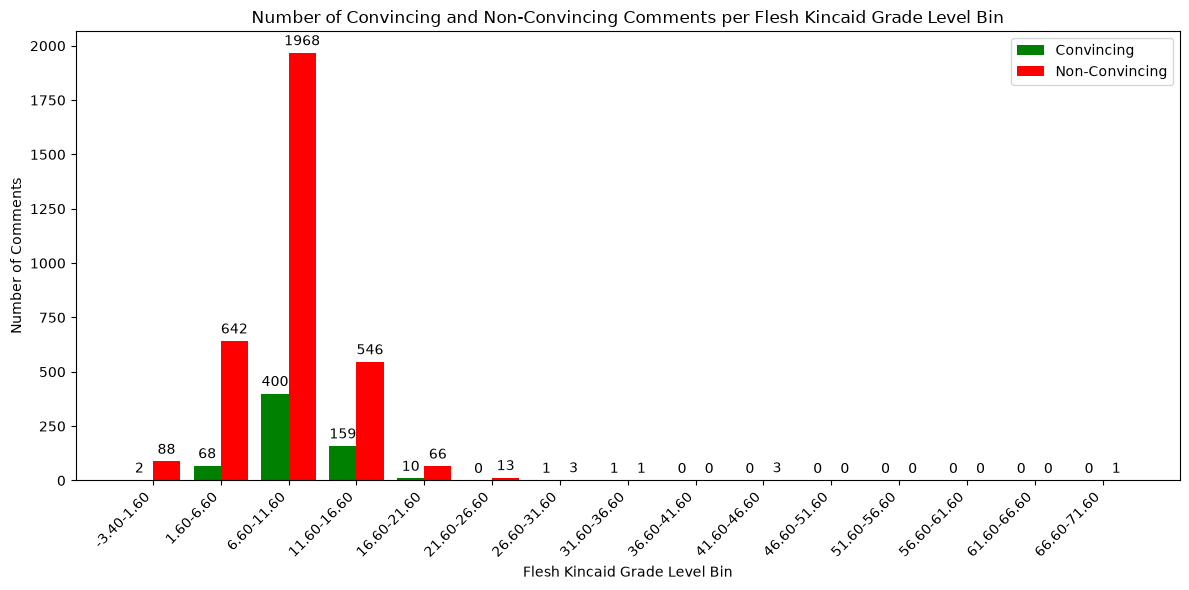

In [72]:
plot_feature('fk_grade_level_converted', 'Flesh Kincaid Grade Level', 5)

In [73]:
max_grade_level_row = comments_df.loc[comments_df['fk_grade_level_converted'].idxmax()]
print(f"Example for high FK grade level ({max_grade_level_row['fk_grade_level_converted']}):")
print(max_grade_level_row['final_comment'])
print("-" * 20)


Example for high FK grade level (70.31):
 619   923   799   504   767   802   806   229   757   781
 340   963    79   800   508   656   123   349   282   361
 825   516   597   245   928   713   815   749   913   391
 613   809   320   142   310   684    23    99    36   788
 503   660   140   753     4   144   648   158   889   601
 556   552   814   477   541   530   487   421   356   635
 251   339   186    65    10   906   876   402   642   605
 828   440   478    74   603   405    56   255   750   897
 492   873   355    86   943   467   576    98   403   546
 118   524   509   692   220   197   728   235   604   333
 551   893   846   914   247   658   644   641     6   456
 681   773   223   607   677   820   393    72   593   469
 899     3   289   464   966   238   288   169   386    71
 435     5   241   434   279   737   479   265   281   683
 554   679   269   387   208   133   324   534   353   296
 471   237   176   813   453   129   502   807   177   716
 772   598   63

In [74]:
comments_df['fk_grade_level'] = comments_df['fk_grade_level_converted']
comments_df.drop(columns=['fk_grade_level_converted'], inplace=True)

### Flesh Kincaid Reading Ease

In [ ]:
comments_df['fk_reading_ease'] = None

In [ ]:
do_calc_feature("fk_reading_ease", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

In [ ]:
comments_df['fk_reading_ease'].head()

In [ ]:
comments_df['fk_reading_ease'] = pd.to_numeric(comments_df['fk_reading_ease'], errors='coerce')

In [ ]:
comments_df['fk_reading_ease'].describe()

In [ ]:
plot_feature('fk_reading_ease', 'Flesh Kincaid Reading Ease', 20)

In [ ]:
min_row = comments_df.loc[comments_df['fk_reading_ease'].idxmin()]
print(f"Example for very low FK reading ease ({min_row['fk_reading_ease']}):")
print(min_row['final_comment'])
print("-" * 20)


## 6.7 Use of Evidence

The paper, "[Attitude Change on Reddit's Change My View](https://jpriniski.github.io/papers/cogsci-reddit.pdf)," explores how individuals on the Reddit forum **Change My View (CMV)** adjust their beliefs on various topics, particularly focusing on sociomoral issues (e.g., politics, morality) compared to non-sociomoral topics (e.g., humor, fiction).

The studuy includes the code for calculating evidence use in comments. We will adapt the code from their [repo in GitHub](https://github.com/jpriniski/CMV), and execute it on our own dataset, to create the evidence use features.

In [ ]:
extensions = ['http://', 'https://', '.com', '.org', '.gov', 'pdf', '.net', 'www.']

stems = ['data', 'stat', 'statist', 'figur', '%', 'percent', 'averag', 'number', 'amount',
         'thousand', 'million', 'billion', '$', '€', '¥', '£', 'dollar', 'evid', 'info',
         'testimoni', 'conclus', 'document', 'experi', 'experi', 'measur', 'measur', 'report',
         'result', 'census', 'figur', 'plot', 'graph', 'sum', 'total', 'decim', 'digit', 'fraction',
         'numer', 'half', 'share', 'proport', 'capit', 'cash', 'properti', 'salari', 'wage', 'wealth',
         'financ', 'resourc', 'roll', 'treasuri', 'bank', 'deposit', 'exchang', 'safe', 'estim', 'price',
         'price', 'merchandis', 'retail', 'sale', 'cartel', 'invest', 'market', 'deposit', 'document',
         'indic', 'wit', 'affirm', 'corrobor', 'declar', 'good', 'ground', 'token', 'signific', 'probabl',
         'p valu', '<', '=', 'greater', 'equal', 'less', 'rang', 'devi', 'sd', 'mode',
         'median']

import nltk
snow = nltk.stem.SnowballStemmer('english')

def get_evidence_count(text):
    evidence_count = 0
    comment_stemmed = snow.stem(text.lower())

    for word in comment_stemmed.split():
      if any(s == word for s in stems) and not any(e in word for e in extensions):
          evidence_count += 1

    return evidence_count

In [ ]:
comments_df['evidence_count'] = None

In [ ]:
do_calc_feature("evidence_count", get_evidence_count)

In [ ]:
comments_df['evidence_count'].describe()

In [ ]:
comments_df['evidence_count'] = pd.to_numeric(comments_df['evidence_count'])

In [ ]:
comments_df['evidence_count'].describe()

In [ ]:
plot_feature('evidence_count', 'Evidence Count', 3)

In [ ]:
max_row = comments_df.loc[comments_df['evidence_count'].idxmax()]
print(f"Example for high evidence count ({max_row['evidence_count']}):")
print(max_row['thread_text'])
print(max_row['final_comment'])
print("-" * 20)

# ７. The relation between comments and Original Post

We think that it is possible that a correlation between the comments style, tone etc. and the same features for the original post (OP) may be an indicator for the persuasion of a comment.

Therefore, we will create all the features also for the OP, and include them too as input for the model.

Since many of our commnets share the same original post, we will temporarily create a dataframe with the unique OPs. We will calculate the features for these unique values (to save time), and then we will copy these values into the original dataframe.

In [ ]:
op_df = comments_df['original_post'].drop_duplicates()
op_df.reset_index(drop=True, inplace=True)
op_df = pd.DataFrame(op_df)
op_df

## 7.1 Sentiment Analysis

In [ ]:
op_df["sentiment_op"] = op_df['original_post'].apply(get_sentiment)

op_df.describe()

In [ ]:
untrusted_features.append('sentiment_op')  # same distrusted VADER method used for comments' sentiment_vader


## 7.2 Tone

In [ ]:
op_df['tone_google_op'] = None

import re

def get_tone_from_google_ai_op_batch(rows):
  texts = [row['original_post'] for row in rows]

  numbered_texts = "\n\n".join(f"{i}:\n{text}" for i, text in enumerate(texts))
  user_prompt = user_prompt_prefix + numbered_texts
  response = generate_content_with_retry(model=GEMINI_MODEL, contents=user_prompt)

  if response.text is None:
    reason = response.candidates[0].finish_reason if response.candidates else response.prompt_feedback
    raise BlockedResponseError(f"empty response, likely safety-blocked (reason: {reason})")

  classifications = [None] * len(texts)
  for line in response.text.strip().splitlines():
    match = re.match(r'\s*(\d+)\s*[:\-]\s*(\w+)', line)
    if match:
      i, label = int(match.group(1)), match.group(2)
      if 0 <= i < len(classifications):
        classifications[i] = label
  return classifications


In [ ]:
BATCH_SIZE = 20

def classify_tone_batch_op(batch_index):
  try:
    classifications = get_tone_from_google_ai_op_batch([op_df.loc[i] for i in batch_index])
    for i, classification in zip(batch_index, classifications):
      op_df.at[i, 'tone_google_op'] = classification
  except BlockedResponseError as e:
    if len(batch_index) == 1:
      print(f"row {batch_index[0]} has no usable response: {e} - marking as 'BLOCKED'")
      op_df.at[batch_index[0], 'tone_google_op'] = 'BLOCKED'
    else:
      mid = len(batch_index) // 2
      classify_tone_batch_op(batch_index[:mid])
      classify_tone_batch_op(batch_index[mid:])

pending_index = op_df[op_df['tone_google_op'].isna()].index
# this loop can be executed multiple times until all entries were classified - each run only retries rows still missing a label
for start in range(0, len(pending_index), BATCH_SIZE):
  batch_index = pending_index[start:start + BATCH_SIZE]
  try:
    classify_tone_batch_op(batch_index)
    op_df.to_csv('../results/op_df_tone_checkpoint.csv', index=False)
    print(f"classified rows {batch_index[0]}-{batch_index[-1]}")
  except genai_errors.ClientError as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed: {e}")
    print("this looks like a quota error, not a transient one - further batches today would just fail too. stopping; re-run this cell after the quota resets.")
    break
  except Exception as e:
    print(f"batch {batch_index[0]}-{batch_index[-1]} failed, will retry on next run: {e}")


## 7.4 Adjective-Adverb Ratio

In [ ]:
op_df['adj_adv_ratio_op'] = None

In [ ]:
do_calc_feature_op("adj_adv_ratio_op", get_adjective_adverb_ratio)

In [ ]:
op_df['adj_adv_ratio_op'].describe()

In [ ]:
op_df['adj_adv_ratio_op'].replace(np.inf, 0).describe()

In [ ]:
finite_max = op_df['adj_adv_ratio_op'].replace(np.inf, np.nan).max()
sentinel = finite_max + 2  # small margin above the real max keeps infinite-ratio rows the highest without distorting the plot
op_df['adj_adv_ratio_op'] = op_df['adj_adv_ratio_op'].replace(np.inf, sentinel)

## 7.5 Readability - Grade Level

In [ ]:
op_df['fk_grade_level_op'] = None

import textstat
do_calc_feature_op("fk_grade_level_op", lambda text: textstat.flesch_kincaid_grade(text), remove_urls=True)

## 7.6 Readability - Reading Ease

In [ ]:
op_df['fk_reading_ease_op'] = None

do_calc_feature_op("fk_reading_ease_op", lambda text: textstat.flesch_reading_ease(text), remove_urls=True)

## 7.7 Evidence Use

In [ ]:
op_df['evidence_count_op'] = None

do_calc_feature_op("evidence_count_op", get_evidence_count)

## Save intermediate output for `03.2`

The heavy notebook loads these, adds the GPU-based features, merges `op_df` into `comments_df`, and saves the final `cmv_comments_df.csv`.

In [ ]:
comments_df.to_csv('../results/comments_df_light.csv', index=False)
op_df.to_csv('../results/op_df_light.csv', index=False)

import json
with open('../results/untrusted_features_light.json', 'w') as f:
    json.dump(untrusted_features, f, indent=2)

print(f'Saved comments_df_light.csv ({len(comments_df)} rows), op_df_light.csv ({len(op_df)} rows), untrusted_features_light.json: {untrusted_features}')
